In [14]:
# Enables the autoreload extension, which reloads modules automatically before executing code.
%load_ext autoreload

# Sets the autoreload mode to automatically reload all modules (level 2) every time a function is called.
%autoreload 2

# Imports the matplotlib library and its pyplot interface, which is commonly used for plotting graphs.
import matplotlib.pyplot as plt
import itertools

# Imports dataset_recipes from the GluonTS dataset repository, which provides access to various time series datasets.
from gluonts.dataset.repository import dataset_recipes

# Imports the get_gluonts_test_dataset function from the eval_util.data module in the uni2ts package.
# This function is likely used to retrieve test datasets compatible with GluonTS for evaluation purposes.
from uni2ts.eval_util.data import get_gluonts_test_dataset

# Imports the plot_next_multi function from the eval_util.plot module in the uni2ts package.
# This function is likely used to plot multiple time series forecast results.
from uni2ts.eval_util.plot import plot_next_multi

# Imports MoiraiForecast and MoiraiModule from the model.moirai module in the uni2ts package.
# MoiraiForecast is probably the class handling the forecasting model, while MoiraiModule is a module related to the Moirai framework.
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Settings
SIZE: model size, select the model size of Moirai to perform inference with

CTX: context length, how many time steps the model will take as input for inference

PSZ: patch size, how many time steps to perform patching with

BSZ: batch size, number of samples in each batch for inference

In [15]:
SIZE = "small"  # model size: choose from {'small', 'base', 'large'}
CTX = 1000  # context length: any positive integer
PSZ = "auto"  # patch size: choose from {"auto", 8, 16, 32, 64, 128}
BSZ = 32  # batch size: any positive integer

### Prepare datasets and model

In [16]:
# List of available datasets:
sorted(dataset_recipes.keys())

['ETTh1',
 'ETTh2',
 'ETTm1',
 'ETTm2',
 'METR_LA',
 'airpassengers',
 'australian_electricity_demand',
 'bitcoin',
 'bitcoin_with_missing',
 'car_parts_with_missing',
 'car_parts_without_missing',
 'cif_2016',
 'cif_2016_12',
 'cif_2016_6',
 'constant',
 'covid_deaths',
 'covid_mobility',
 'dominick',
 'elecdemand',
 'electricity',
 'electricity_hourly',
 'electricity_nips',
 'electricity_weekly',
 'exchange_rate',
 'exchange_rate_nips',
 'extended_web_traffic_with_missing',
 'fred_md',
 'hospital',
 'istanbul_traffic',
 'jena_weather',
 'kaggle_web_traffic_weekly',
 'kaggle_web_traffic_with_missing',
 'kaggle_web_traffic_without_missing',
 'kdd_cup_2018_with_missing',
 'kdd_cup_2018_without_missing',
 'london_smart_meters_with_missing',
 'london_smart_meters_without_missing',
 'm1_monthly',
 'm1_quarterly',
 'm1_yearly',
 'm3_monthly',
 'm3_other',
 'm3_quarterly',
 'm3_yearly',
 'm4_daily',
 'm4_hourly',
 'm4_monthly',
 'm4_quarterly',
 'm4_weekly',
 'm4_yearly',
 'm5',
 'monash_m3_

In [48]:
# Loads the test dataset using the 'get_gluonts_test_dataset' function.
# 'electricity' refers to the specific dataset being loaded (the electricity dataset).
# 'prediction_length=None' means that the default prediction length for the dataset will be used.
# 'regenerate=False' indicates that the dataset should not be regenerated if it already exists in the cache.
test_data, metadata = get_gluonts_test_dataset(
    "electricity", prediction_length=None, regenerate=False
)

# Displays the metadata of the dataset, which usually contains information like the frequency, prediction length, and dataset fields.
metadata

MetaData(freq='1H', target_dim=1, prediction_length=24, feat_dynamic_real_dim=0, past_feat_dynamic_real_dim=0, split='test')

In [49]:
# Initializes the MoiraiForecast model by loading a pretrained MoiraiModule from Salesforce.
# 'SIZE' is a placeholder variable that likely refers to the model size (e.g., small, medium, large).
# 'f"Salesforce/moirai-1.1-R-{SIZE}"' dynamically loads the model from the Salesforce repository.
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(
        f"Salesforce/moirai-1.1-R-{SIZE}",
    ),
    
    # Sets the prediction length based on the metadata from the dataset, defining how many future time steps the model should predict.
    prediction_length=metadata.prediction_length,
    
    # Defines the context length (CTX) which indicates how many past time steps are used to make the forecast.
    context_length=CTX,
    
    # Sets the patch size (PSZ), which could refer to the number of time steps processed together for certain operations in the model.
    patch_size=PSZ,
    
    # Specifies the number of samples for probabilistic forecasting. In this case, 100 different forecasts are generated per time series.
    num_samples=100,
    
    # Defines the target dimension, i.e., the number of variables or features being predicted, based on the dataset metadata.
    target_dim=metadata.target_dim,
    
    # Sets the dimension of the dynamic real-valued features for the current prediction window based on the dataset metadata.
    feat_dynamic_real_dim=metadata.feat_dynamic_real_dim,
    
    # Sets the dimension of the past dynamic real-valued features (historical features) using the metadata.
    past_feat_dynamic_real_dim=metadata.past_feat_dynamic_real_dim,
)

# Creates a predictor from the model, which will handle the inference (making predictions) with a specified batch size (BSZ).
predictor = model.create_predictor(batch_size=BSZ)

# Uses the predictor to generate forecasts on the test dataset. 'test_data.input' contains the input data for forecasting.
forecasts = predictor.predict(test_data.input)

#########################################################################
# Create iterators for input, label, and forecast data
# Converts the input data from the test set into an iterator for sequential access.
input_it = iter(test_data.input)  # Create an iterator to go through the input data

# Converts the labels (actual values) from the test set into an iterator for sequential access, allowing for evaluation.
label_it = iter(test_data.label)  # Create an iterator to go through the true labels (ground truth)

# Converts the forecasted values into an iterator for sequential access, enabling comparison with actual values and further processing.
forecast_it = iter(forecasts)  # Create an iterator to go through the forecasted predictions

# Copy iterator
input_it1, input_it2 = itertools.tee(input_it, 2)
label_it1, label_it2 = itertools.tee(label_it, 2)
forecast_it1, forecast_it2 = itertools.tee(forecast_it, 2)
print('\n'*3)

# Check the data stored in input_it
print("##################################")
print("Check the data stored in input_it")
print("##################################")
for idx, item in enumerate(input_it1):
    if idx == 0:
        print(item)  # iterator의 모든 데이터를 순차적으로 출력
        print(item["target"].shape)
        # print(item["feat_dynamic_real"].shape)
        # print(item["past_feat_dynamic_real"].shape)
    else:
        break
print('\n'*3)

# Check the data stored in label_it
print("##################################")
print("Check the data stored in label_it")
print("##################################")
for idx, item in enumerate(label_it1):
    if idx == 0:
        print(item)  # iterator의 모든 데이터를 순차적으로 출력
        print(item["target"].shape)
        # print(item["feat_dynamic_real"].shape)
        # print(item["past_feat_dynamic_real"].shape)
    else:
        break
print('\n'*3)

# Check the data stored in forecast_it
print("####################################")
print("Check the data stored in forecast_it")
print("####################################")
for idx, item in enumerate(forecast_it1):
    if idx == 0:
        print(item)  # iterator의 모든 데이터를 순차적으로 출력
        print(item.samples.shape)  # (num_samples, PDT, target_dim) = (100, 20, 10)
    else:
        break
print('\n'*3)





##################################
Check the data stored in input_it
##################################
{'target': array([14., 18., 21., ...,  6.,  9.,  7.], dtype=float32), 'start': Period('2012-01-01 00:00', 'H'), 'feat_static_cat': array([0], dtype=int32), 'item_id': 0}
(21044,)




##################################
Check the data stored in label_it
##################################
{'target': array([ 9., 10., 22., 20., 13., 12., 13., 13., 12., 13., 11., 10.,  8.,
       23.,  6.,  2.,  2.,  2.,  4.,  2.,  6.,  8.,  8.,  6.],
      dtype=float32), 'start': Period('2014-05-26 20:00', 'H'), 'feat_static_cat': array([0], dtype=int32), 'item_id': 0}
(24,)




####################################
Check the data stored in forecast_it
####################################
gluonts.model.forecast.SampleForecast(info=None, item_id='0', samples=array([[  2.3854942,   4.003784 ,   9.149859 , ...,   9.723543 ,
          9.770208 ,   7.284053 ],
       [  7.7642107,   9.723758 ,   6.6311274,

### Make predictions

In [50]:
# Retrieves the next element from the 'input_it' iterator, which corresponds to the input data (lookback window) for the forecast.
# The lookback window represents the historical data that will be used by the model to make predictions.
inp = next(input_it2)  # input / lookback window

# Retrieves the next element from the 'label_it' iterator, which represents the actual values (label) for the forecast horizon.
# The forecast horizon is the future time period for which predictions are made, and these labels serve as the ground truth for evaluation.
label = next(label_it2)  # label / forecast horizon

# Retrieves the next forecast object from the 'forecast_it' iterator, which is a GluonTS Forecast object containing the model's predictions.
# The forecast object can store multiple samples and other information about the predicted future values.
forecast = next(forecast_it2)  # predictions (GluonTS Forecast object)


In [51]:
inp.keys(), label.keys()

(dict_keys(['target', 'start', 'feat_static_cat', 'item_id']),
 dict_keys(['target', 'start', 'feat_static_cat', 'item_id']))

In [52]:
inp["target"].shape, label["target"].shape

((21044,), (24,))

Moirai produces a _probabilistic forecast_, in the form of a mixture distribution.
```forecast``` is a sample forecast, taking ```num_samples=100``` samples from the mixture distribution per time step.

In [53]:
forecast.samples.shape

(100, 24)

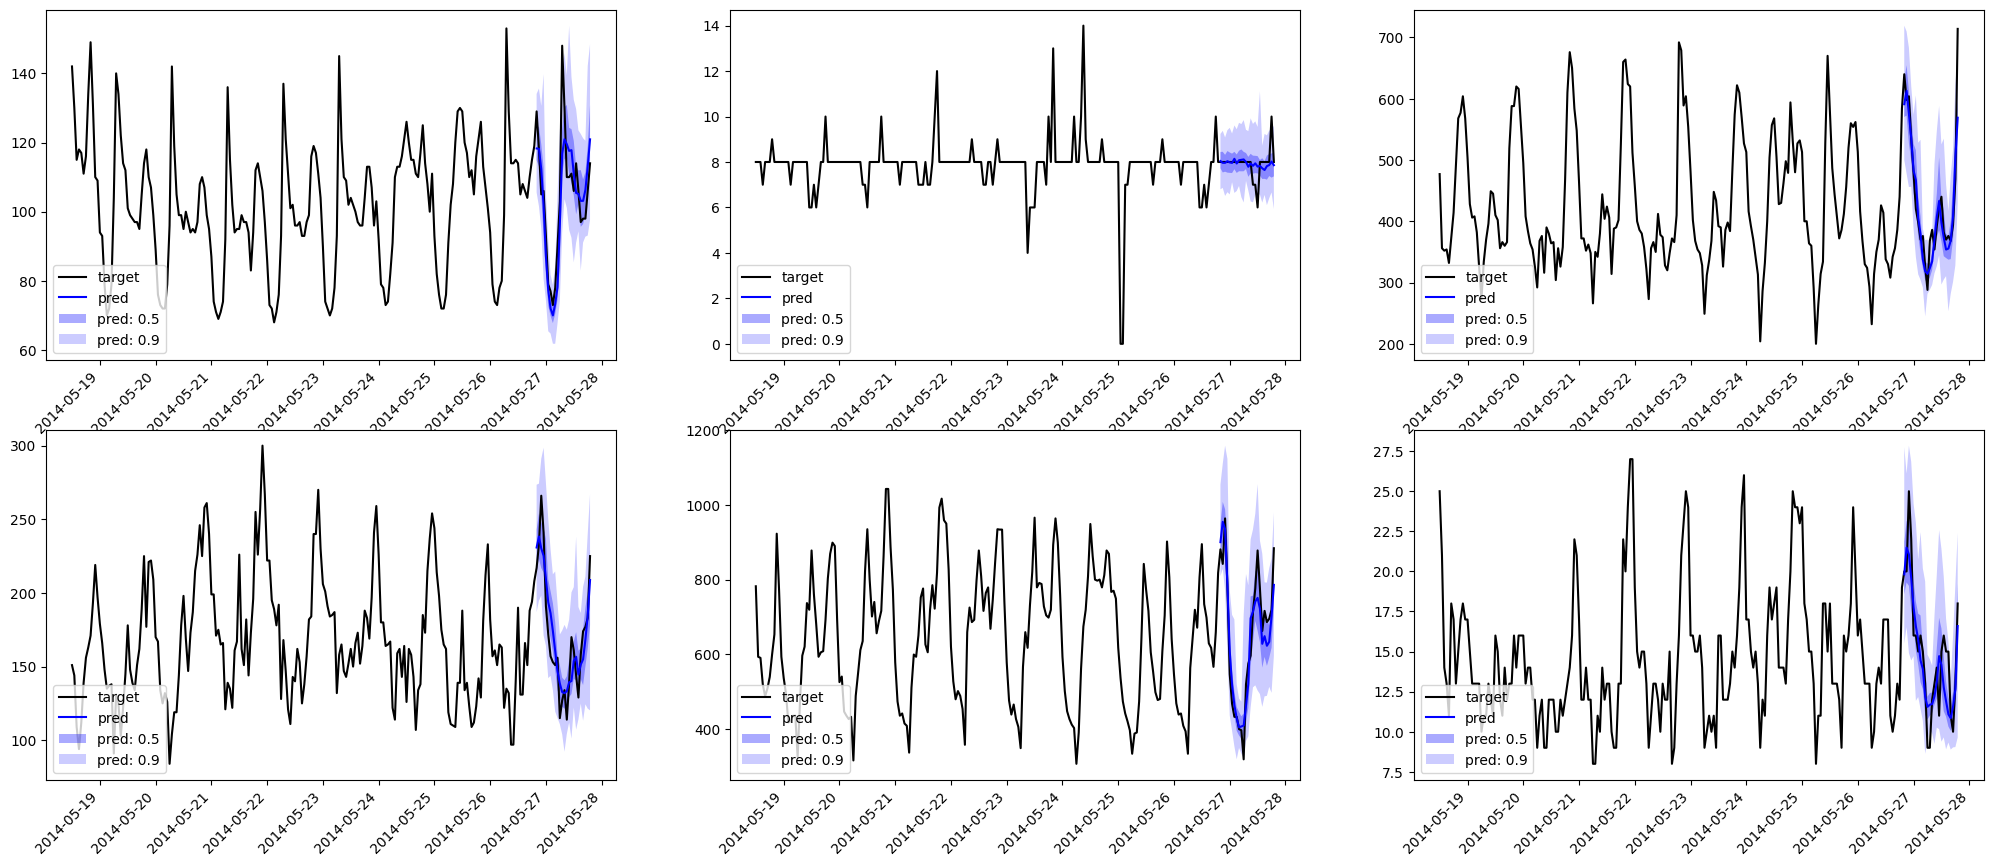

In [54]:
# Visualize forecasts
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
plot_next_multi(
    axes,
    input_it2,
    label_it2,
    forecast_it2,
    context_length=200,
    intervals=(0.5, 0.9),
    dim=None,
    name="pred",
    show_label=True,
)